In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def plot_decision_boundary_keras(clf, X, Y, h=0.01, strict=False):
    """Вспомогательная функция для визуализации решения"""
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])[:, 0]
    Z = Z.reshape(xx.shape)
    Z_strict = Z >= 0.5

    plt.figure(figsize=(15, 15))
    if strict:
        plt.contourf(xx, yy, Z_strict, cmap=plt.cm.Blues, alpha=0.8);
    else:
        plt.contourf(xx, yy, Z, cmap=plt.cm.Blues, alpha=0.8);

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.autumn);
    plt.title('Граница принятия решения');

In [3]:
def generate_dataset():
    """Создание набора данных"""
    ps = []
    for a in np.linspace(0, 2*np.pi, 1000):
        if (0.75*np.pi - 0.2) < a < (0.75*np.pi + 0.2):
            continue
        if (7.0*np.pi/4.0 - 0.2) < a < (7.0*np.pi/4.0 + 0.2):
            continue
        if (5.0*np.pi/4.0 - 0.2) < a < (5.0*np.pi/4.0 + 0.2):
            continue
        r = 1 + (np.random.rand()-0.5)*0.5
        x = np.cos(a)*r
        y = np.sin(a)*r
        ps.append([x,y])
    ps = np.array(ps)

    xs = np.linspace(-1.5, 1.5, 200)
    xs = xs + (np.random.rand(len(xs)) - 0.5)/10.0
    ys = -xs + (np.random.rand(len(xs)) - 0.5)/3.0

    xs2 = np.linspace(-1.5, -0.1, 200)
    xs2 = xs2 + (np.random.rand(len(xs2)) - 0.5)/10.0
    ys2 = xs2 + (np.random.rand(len(xs2)) - 0.5)/3.0

    ps2 = np.vstack([np.array([xs, ys]).T,
                     np.array([xs2, ys2]).T])

    X = np.vstack([ps, ps2])
    y = np.array([0]*ps.shape[0] + [1]*ps2.shape[0])

    return X, y

In [4]:
X, y = generate_dataset()

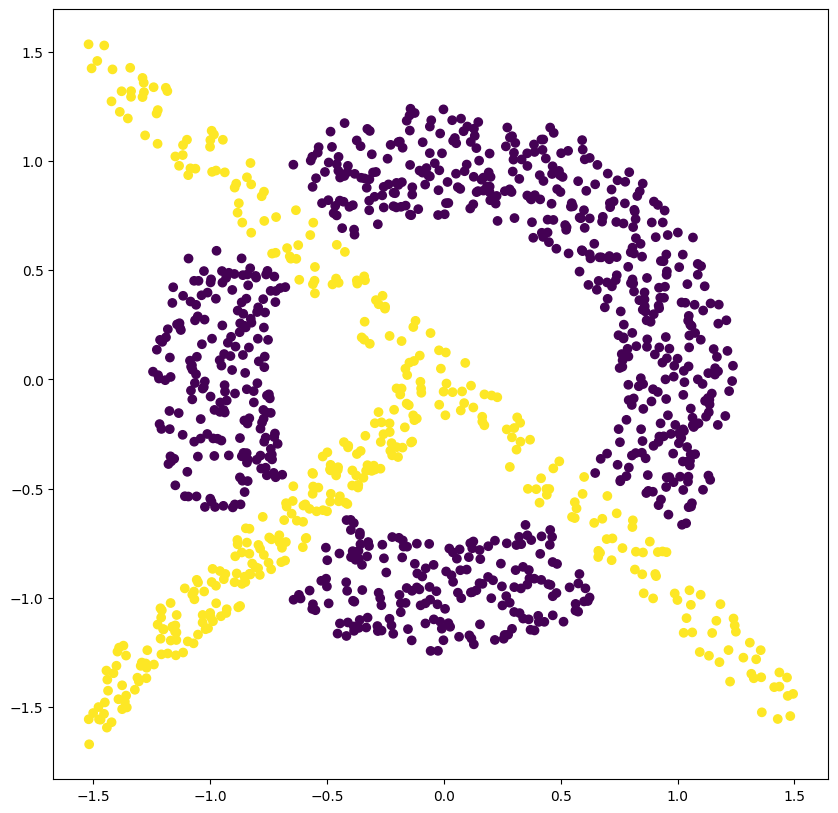

In [5]:
plt.figure(figsize=(10,10))
plt.scatter(X[:,0], X[:,1], c=y);

In [15]:
# Задание 1: Своя нейронная сеть
from keras.models import Sequential
from keras.layers import Dense, Input
from livelossplot import PlotLossesKeras

import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

In [16]:
# Создаем модель с оптимальной архитектурой (исправленная версия)
# Для разделения двух фигур достаточно небольшой сети
model = Sequential([
    Input(shape=(2,)),  # Правильный способ указать входную форму
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    # Выходной слой: 1 нейрон с сигмоидой для бинарной классификации
    Dense(1, activation='sigmoid')
])

In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Оптимальные параметры для обучения
batch_size = 32  # Размер батча - компромисс между скоростью и стабильностью
epochs = 100     # Достаточно для сходимости

In [19]:
model.compile('sgd', loss='binary_crossentropy', metrics=['accuracy'])

In [37]:
# Обучаем модель с визуализацией процесса
history = model.fit(X, y, batch_size=batch_size, epochs=epochs, verbose=0,
                    validation_split=0.2,
                    callbacks=[PlotLossesKeras()])

accuracy
	training         	 (min:    0.918, max:    1.000, cur:    0.999)
	validation       	 (min:    0.128, max:    0.194, cur:    0.190)
Loss
	training         	 (min:    0.026, max:    0.166, cur:    0.026)
	validation       	 (min:    5.228, max:   17.527, cur:   17.527)


3030/3030 ━━━━━━━━━━━━━━━━━━━━ 1s 378us/step


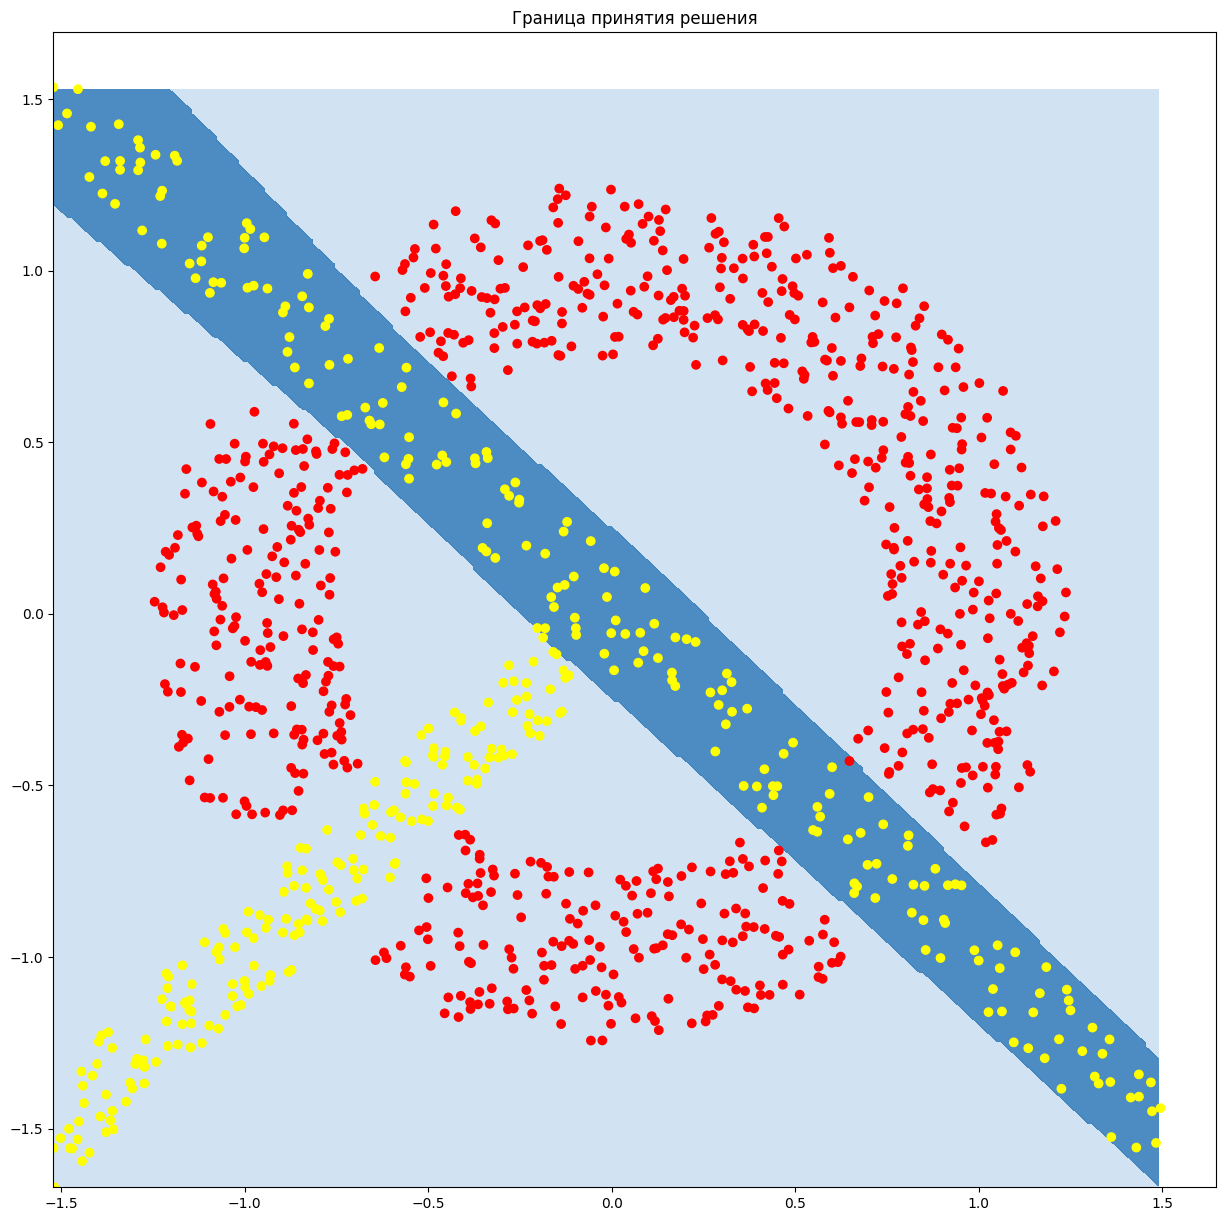

In [38]:
# Визуализируем границу принятия решения
plot_decision_boundary_keras(model, X, y, strict=True)
plt.show()

In [39]:
# Задание 2: Оптимайзер
from keras.optimizers import *

In [23]:
# Функция создания нейронной сети с параметрами, найденными выше
def create_model():
    return Sequential([
        Dense(64, activation='relu', input_shape=(2,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

In [24]:
# Тестируем различные скорости обучения
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5]
histories = []
models = []  # Сохраняем модели для последующей визуализации

for lr in learning_rates:
    print(f"\n=== Обучение с learning_rate = {lr} ===")
    # Создаем новую модель с инициализированными весами
    model_lr = create_model()

    # Создаем оптимизатор SGD с конкретным lr
    sgd = SGD(learning_rate=lr)
    model_lr.compile(sgd, loss='binary_crossentropy', metrics=['accuracy'])

    # Обучаем модель
    history = model_lr.fit(X, y, batch_size=32, epochs=50, verbose=0)

    histories.append(history)
    models.append(model_lr)


=== Обучение с learning_rate = 0.0001 ===

=== Обучение с learning_rate = 0.001 ===

=== Обучение с learning_rate = 0.01 ===

=== Обучение с learning_rate = 0.1 ===

=== Обучение с learning_rate = 0.5 ===


In [25]:
# Извлекаем точности из истории обучения
accuracies = [h.history['accuracy'] for h in histories]

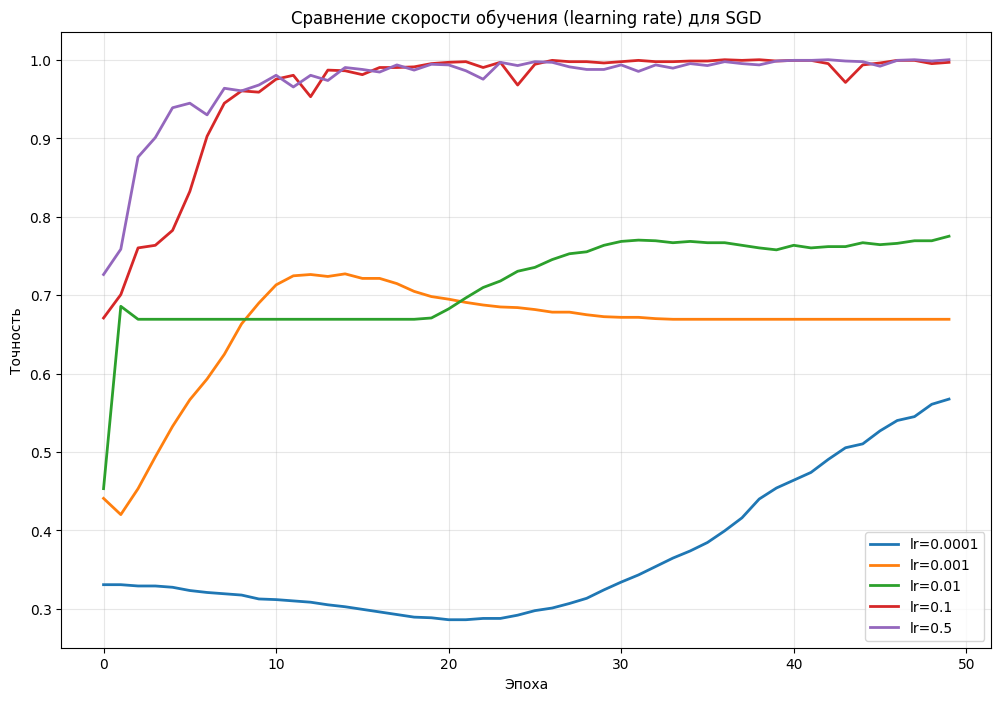

In [26]:
# Визуализируем сравнение скоростей обучения
plt.figure(figsize=(12, 8))
for acc, lr in zip(accuracies, learning_rates):
    plt.plot(acc, label=f'lr={lr}', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.title('Сравнение скорости обучения (learning rate) для SGD')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

3030/3030 ━━━━━━━━━━━━━━━━━━━━ 1s 444us/step


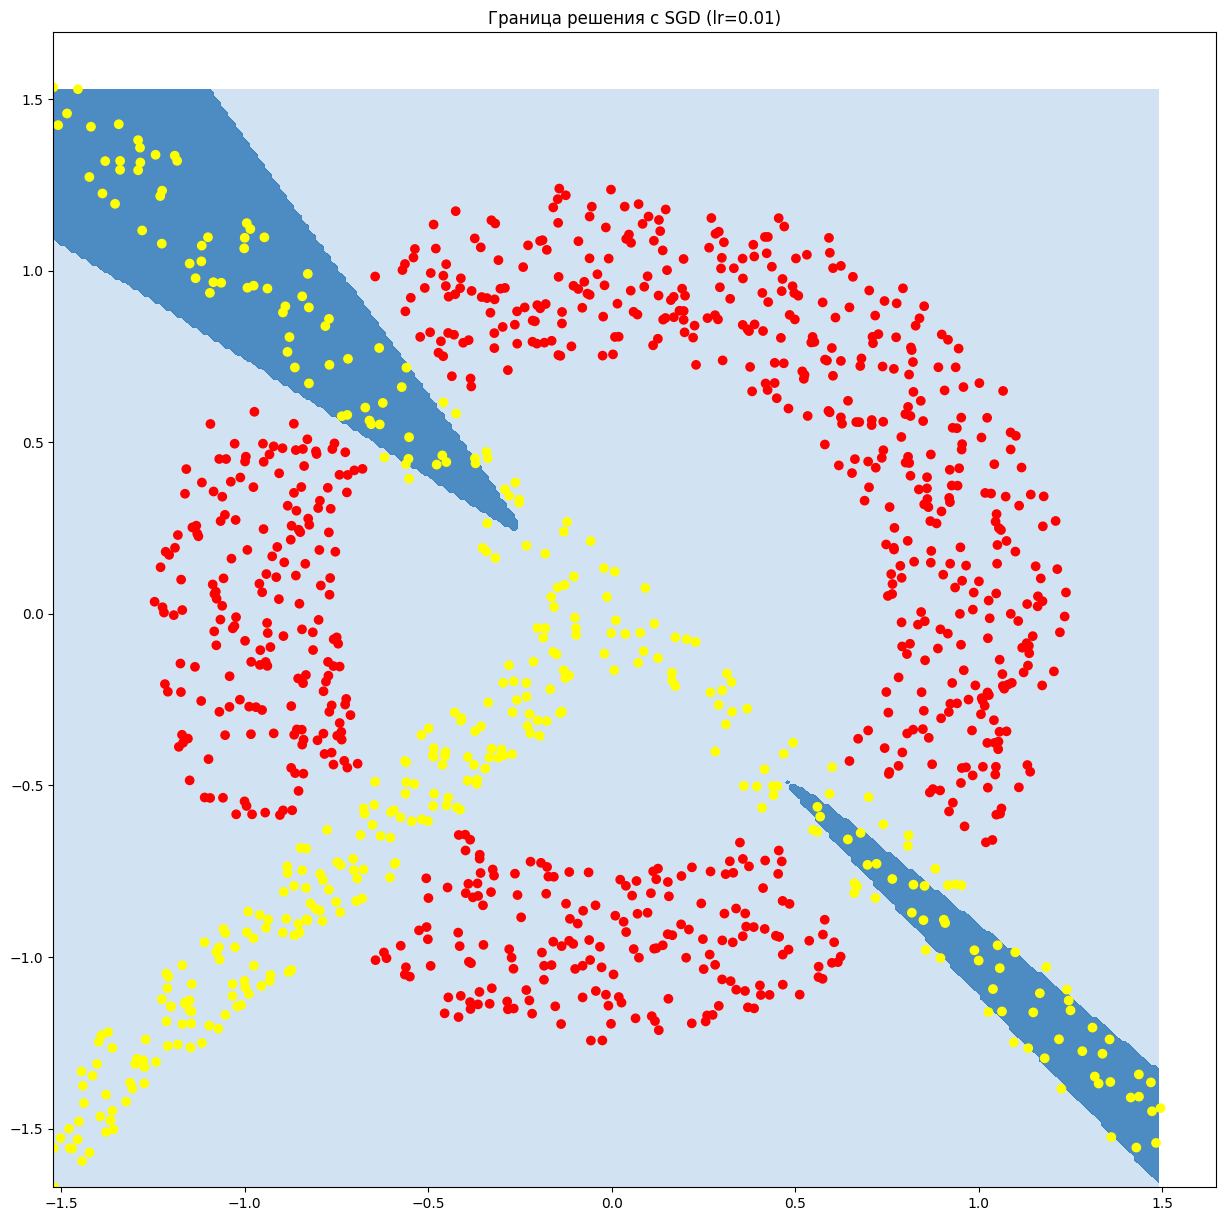

In [27]:
# Визуализируем лучшую модель (с lr=0.01)
best_model_idx = 2  # lr=0.01
plot_decision_boundary_keras(models[best_model_idx], X, y, strict=True)
plt.title(f'Граница решения с SGD (lr=0.01)')
plt.show()

In [28]:
# Задание 3: Инициализация весов
# Функция создания нейронной сети с параметром инициализации
# k_init - конкретное значение инициалайзера для параметра kernel_initializer у каждого слоя
def create_model_with_init(k_init):
    return Sequential([
        Dense(64, activation='relu', kernel_initializer=k_init, input_shape=(2,)),
        Dense(32, activation='relu', kernel_initializer=k_init),
        Dense(16, activation='relu', kernel_initializer=k_init),
        Dense(1, activation='sigmoid', kernel_initializer=k_init)
    ])

In [29]:
# Различные инициализаторы для сравнения
from keras.initializers import RandomNormal, GlorotUniform, HeNormal, RandomUniform

k_init = [
    'random_normal',     # Случайные значения из нормального распределения
    'glorot_uniform',    # Инициализация Ксавье (Xavier)
    'he_normal',         # Инициализация He (для ReLU)
    'random_uniform'     # Равномерное распределение
]

histories_init = []
models_init = []

for k in k_init:
    print(f"\n=== Обучение с инициализацией: {k} ===")
    # Создаем модель с конкретным инициализатором
    model_init = create_model_with_init(k)

    # Компилируем с Adam (лучший из предыдущего задания)
    model_init.compile('adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Обучаем модель
    history = model_init.fit(X, y, batch_size=32, epochs=50, verbose=0)

    histories_init.append(history)
    models_init.append(model_init)


=== Обучение с инициализацией: random_normal ===

=== Обучение с инициализацией: glorot_uniform ===

=== Обучение с инициализацией: he_normal ===

=== Обучение с инициализацией: random_uniform ===


In [30]:
# Извлекаем точности из истории обучения
accuracies_init = [h.history['accuracy'] for h in histories_init]

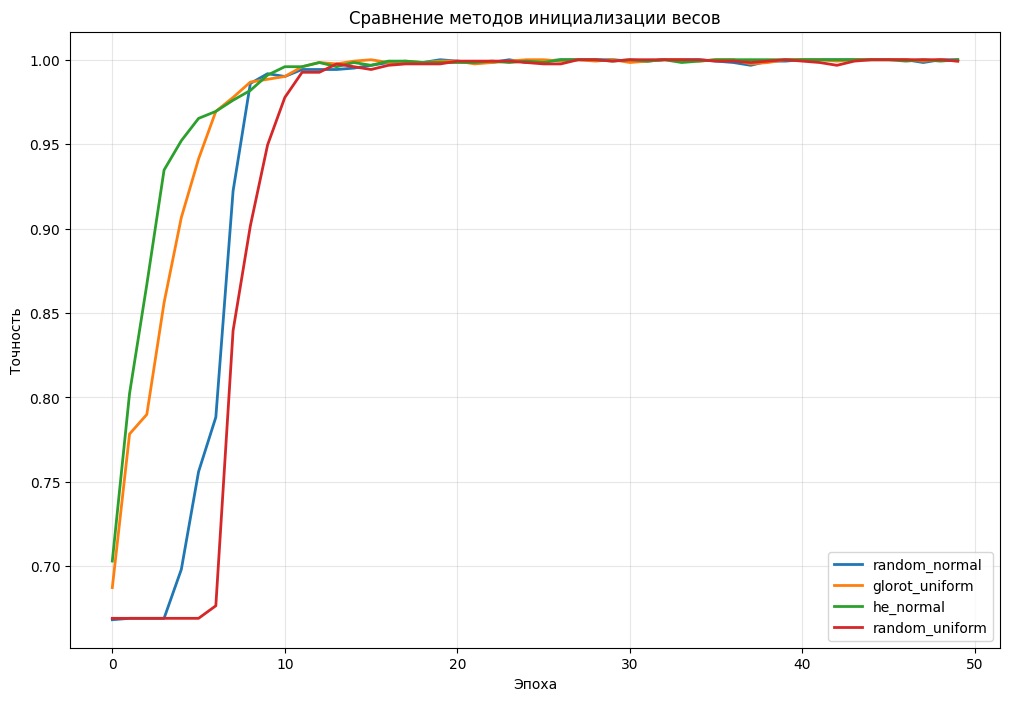

In [31]:
# Визуализируем сравнение инициализаторов
plt.figure(figsize=(12, 8))
for acc, init_name in zip(accuracies_init, k_init):
    plt.plot(acc, label=init_name, linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.title('Сравнение методов инициализации весов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

3030/3030 ━━━━━━━━━━━━━━━━━━━━ 1s 379us/step


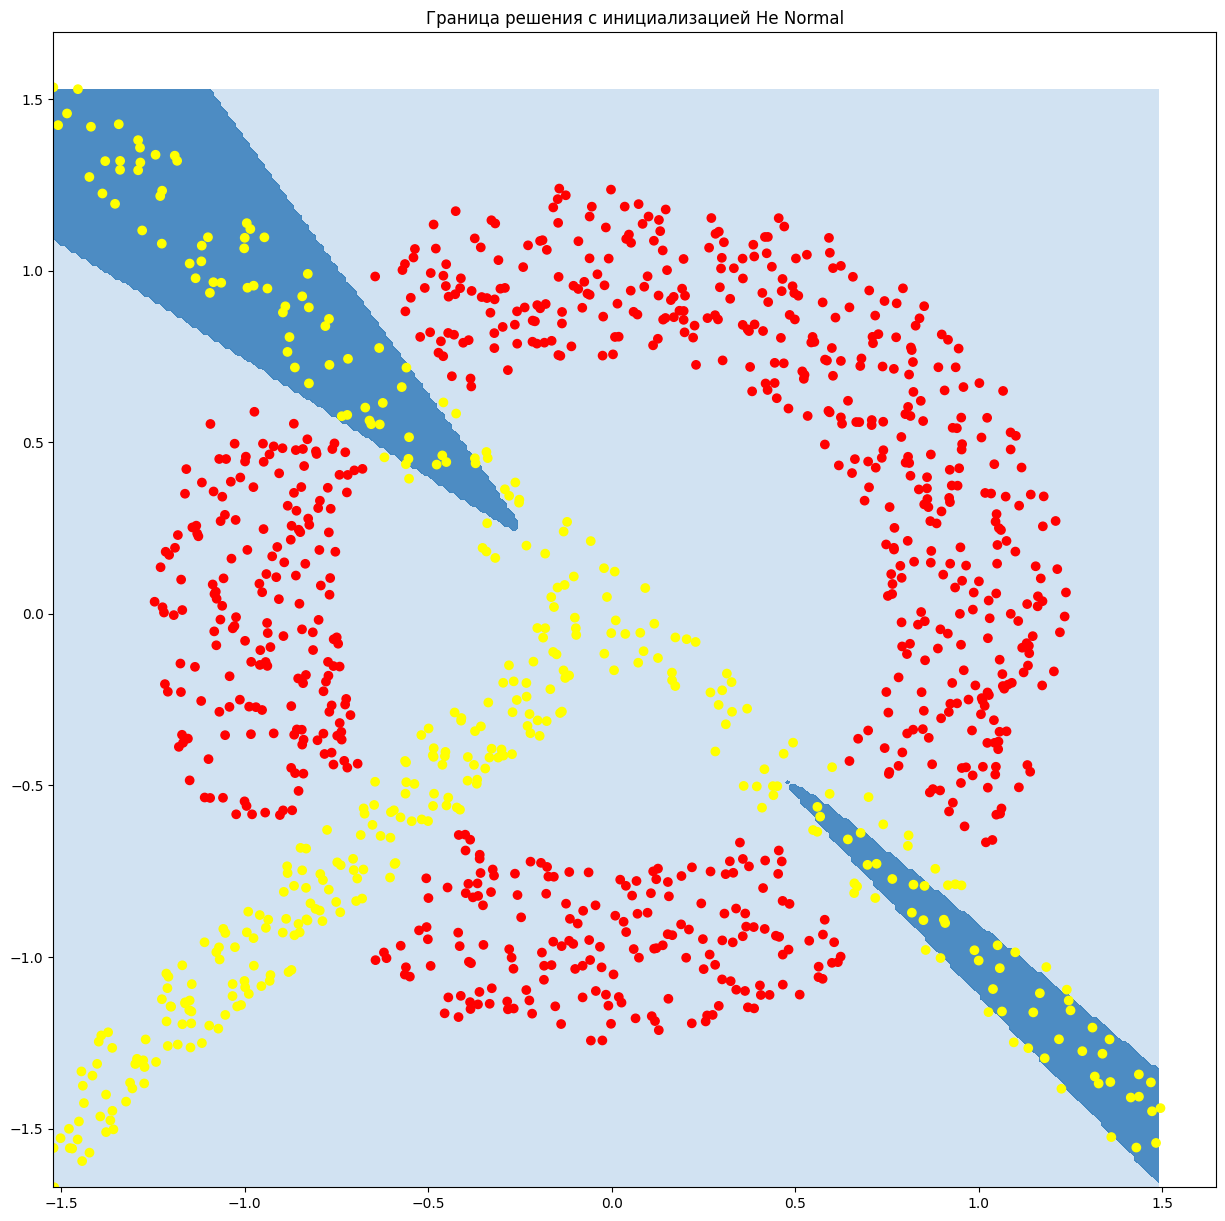

In [32]:
# Визуализируем лучшую модель (He initialization)
best_init_idx = 2  # 'he_normal'
plot_decision_boundary_keras(models_init[best_init_idx], X, y, strict=True)
plt.title(f'Граница решения с инициализацией He Normal')
plt.show()

In [33]:
# Задание 4: Callbacks
from keras.callbacks import EarlyStopping, ModelCheckpoint
import tempfile
import os

# Создаем временную директорию для сохранения моделей
temp_dir = tempfile.mkdtemp()
checkpoint_path = os.path.join(temp_dir, 'model_epoch_{epoch:02d}.h5')

In [34]:
# Создаем модель с оптимальными параметрами
model_final = create_model_with_init('he_normal')
model_final.compile('adam', loss='binary_crossentropy', metrics=['accuracy'])

# Настраиваем колбеки
early_stopping = EarlyStopping(
    monitor='val_loss',      # Отслеживаем валидационную ошибку
    patience=10,             # Останавливаем, если 10 эпох нет улучшений
    verbose=1,
    restore_best_weights=True  # Восстанавливаем лучшие веса
)

model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',   # Отслеживаем точность на валидации
    save_best_only=True,      # Сохраняем только лучшую модель
    verbose=1
)

# Обучаем модель с колбеками
history_final = model_final.fit(
    X, y,
    batch_size=32,
    epochs=200,               # Большое количество эпох
    validation_split=0.2,      # 20% данных для валидации
    callbacks=[PlotLossesKeras(), early_stopping, model_checkpoint],
    verbose=0
)

accuracy
	training         	 (min:    0.832, max:    0.996, cur:    0.996)
	validation       	 (min:    0.000, max:    0.182, cur:    0.182)
Loss
	training         	 (min:    0.049, max:    0.424, cur:    0.049)
	validation       	 (min:    3.076, max:   18.879, cur:   18.879)

Epoch 11: val_accuracy did not improve from 0.18182
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 1.


In [35]:
# Проверяем, какие файлы сохранились
print(f"Сохраненные модели в {temp_dir}:")
saved_models = os.listdir(temp_dir)
for model_file in saved_models:
    print(f"  - {model_file}")

Сохраненные модели в C:\Users\buriy\AppData\Local\Temp\tmpkrjnu52o:
  - model_epoch_01.h5
  - model_epoch_06.h5
  - model_epoch_07.h5
  - model_epoch_09.h5
  - model_epoch_10.h5


3030/3030 ━━━━━━━━━━━━━━━━━━━━ 1s 344us/step


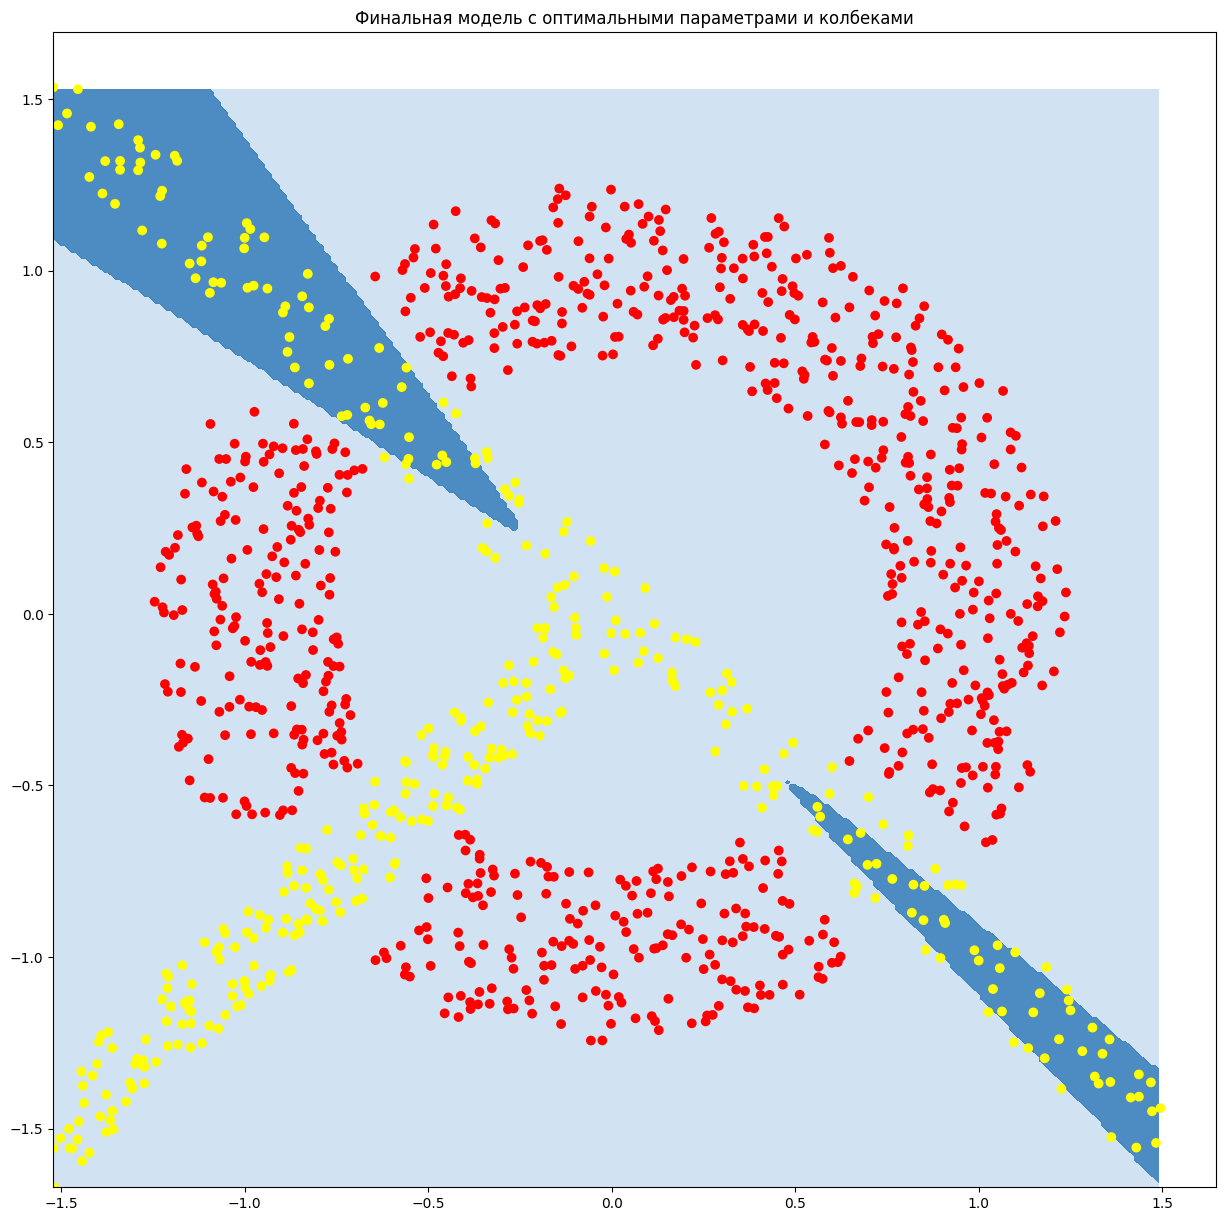

Итоговая точность на обучении: 0.9959
Итоговая точность на валидации: 0.1818


In [36]:
# Финальная визуализация лучшей модели
plot_decision_boundary_keras(model_final, X, y, strict=True)
plt.title('Финальная модель с оптимальными параметрами и колбеками')
plt.show()

# Выводим итоговую точность
train_acc = history_final.history['accuracy'][-1]
val_acc = history_final.history['val_accuracy'][-1]
print(f"Итоговая точность на обучении: {train_acc:.4f}")
print(f"Итоговая точность на валидации: {val_acc:.4f}")